# Simulation of Neutrino Oscillations and Kaon Decay
**2 flavour neutrino oscillation**
\
Initialize flavour state -> Apply PMNS (transform to mass basis) -> Apply Unitary time evolution  -> Apply PMNS† to convert back to flavour basis

In [92]:
#Importing the necessary libraries
import numpy as np                      # math and array operations
import matplotlib.pyplot as plt         # plotting
from matplotlib.patches import Patch    # for legend colored boxes
from scipy.optimize import minimize     # classical optimizer
from qiskit import QuantumCircuit       # build quantum circuits
from qiskit_aer import AerSimulator    # local quantum simulator
from qiskit.circuit import Parameter   # for parameterized quantum circuits
from qiskit.visualization import plot_histogram # for plotting results
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UGate

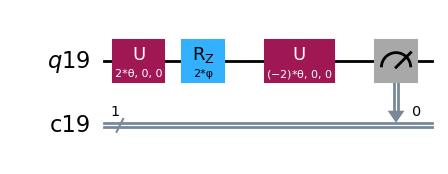

In [93]:
#Creating the circuit
qreg = QuantumRegister(1)              # Number of Qubits
creg = ClassicalRegister(1)            # Number of Classical bits
qc = QuantumCircuit(qreg,creg)         # Create a quantum circuit with 1 qubit and 1 classical bit

SHOTS = 1024                           # shots per circuit 
sim   = AerSimulator()                 # simulator for circuit 

theta = Parameter('θ')                # Define a parameter for the rotation angle (Mixing angle)
phi = Parameter('φ')                  # Define a parameter for the phase time evolution
qc.u(2*theta,0,0,0)                   # Apply a U3 gate to the qubit
qc.rz(2*phi,0)                        # Apply a Rz gate to the qubit
qc.u(-2*theta,0,0,0)                   # Apply a U3 gate to the qubit
qc.measure(qreg,creg)                 # Measure the qubit and store the result in the classical bit
qc.draw('mpl')                        # Draw the circuit

In [94]:
# Define Oscillation parameters
theta_value = 0.5                # Set the value of the mixing angle (θ)

E = 1.0                          # Neutrino energy in GeV
delta_m_squared = 2.5e-3          # Mass-squared difference in eV^2


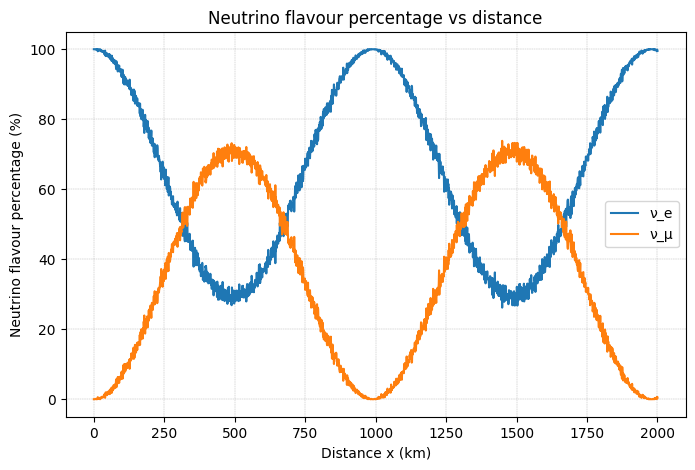

In [95]:
# Plot the oscillations as a function of distance x (in km)
x_km = np.arange(0, 2001, 1)
flavour0_pct = []
flavour1_pct = []

for x in x_km:
    phi_val = 1.27 * delta_m_squared * x / E  #  Set the value of the phase: time evolution (φ)
    qc_bound = qc.assign_parameters({theta: theta_value, phi: phi_val})
    counts = sim.run(qc_bound, shots=SHOTS).result().get_counts()
    flavour0_pct.append(100 * counts.get('0', 0) / SHOTS)
    flavour1_pct.append(100 * counts.get('1', 0) / SHOTS)

plt.figure(figsize=(8, 5))
plt.plot(x_km, flavour0_pct,label='ν_e')
plt.plot(x_km, flavour1_pct,label='ν_μ')
plt.xlabel('Distance x (km)')
plt.ylabel('Neutrino flavour percentage (%)')
plt.title('Neutrino flavour percentage vs distance')
plt.grid(True, which='both', linestyle='--', linewidth=0.31)
plt.legend()
plt.show()

# Kaon Decay
|K_s> -> ∏ ∏ 
|K_L> -> ∏ ∏ ∏ 

**encoding:**
\
|K_s> : |00>
\
|∏∏> (∏∏ decay mode) : |10>
\
|K_L> : |11> 
\
|∏∏∏> (∏∏∏ decay mode) : |01> 

In [96]:
# parameters
t = 1.5 # time evolution parameter
theta_s = 2*np.arctan(np.sqrt(t)*(1.058+0.3*t)) 
theta_L = 2*np.arctan(np.sqrt(t)*(0.044-0.00002*t))

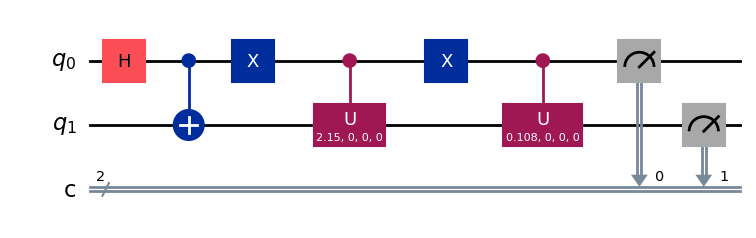

In [99]:
qk=QuantumCircuit(2,2)
qk.h(0)
qk.cx(0,1)
qk.x(0)
qk.cu(theta_s,0,0,0,0,1)
qk.x(0)
qk.cu(theta_L,0,0,0,0,1)
qk.measure([0,1],[0,1])
qk.draw('mpl')

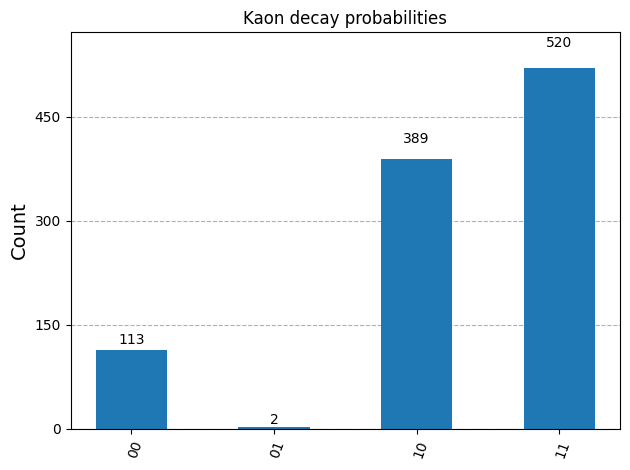

In [110]:
# Aer simulator
counts = sim.run(qk, shots=SHOTS).result().get_counts()
plot_histogram(counts, title="Kaon decay probabilities", bar_labels=True)

